# 🚲 Dublin Bikes Availability Prediction Model

## Project Objective

The goal of this project is to build a machine learning model to predict bike station availability at a given time.  
Using historical bike usage data combined with weather information, the model aims to estimate:

- Number of available bikes (`num_bikes_available`)
- Number of available docks (`num_docks_available`)

---

## Dataset

- **File name:** `final_merged_data.csv`  
- **Description:**  
  This dataset combines:
  - bike station data  
  - Weather data (temperature, humidity, etc.)

---

## Notebook Structure

1. Environment Setup & Data Loading  
2. Data Understanding 
3. Data Cleaning
4. Feature Engineering  
5. Feature Pairing
6. Feature Selection  
7. Model Training & Comparison  
8. Model Selection & Interpretation  
9. Model Saving
10. Model Prediction Example

# 1. Environment Setup & Data Loading 

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

In [5]:
# Load the dataset
df = pd.read_csv("final_merged_data.csv")
df.head(5)

,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,...,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,1,True,True,True,DAME STREET,Dame Street,53.344006,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
1,2024-12-01 00:10:00,100,17,8,True,True,True,HEUSTON BRIDGE (SOUTH),Heuston Bridge (South),53.347107,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
2,2024-12-01 00:10:00,109,20,9,True,True,True,BUCKINGHAM STREET LOWER,Buckingham Street Lower,53.353333,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
3,2024-12-01 00:10:00,11,1,29,True,True,True,EARLSFORT TERRACE,Earlsfort Terrace,53.334293,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
4,2024-12-01 00:10:00,114,4,36,True,True,True,WILTON TERRACE (PARK),Wilton Terrace (Park),53.333652,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083


# 2. Data Understanding & 3.Data Cleaning

In [6]:
# =========================
# Data Quality Checks
# =========================

# Check 1: Dataset is not empty
if df.empty:
    print("WARNING: Dataset is empty!")
else:
    print(f"Dataset contains {df.shape[0]:,} rows")

# Check 2: Duplicate rows
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"WARNING: Found {duplicate_count} duplicate rows")
else:
    print("No duplicate rows found")

# Check 3: Unnamed columns
unnamed_cols = [col for col in df.columns if 'Unnamed' in str(col)]
if unnamed_cols:
    print(f"WARNING: Found {len(unnamed_cols)} unnamed columns:")
    for col in unnamed_cols:
        print(f"  - {col}")
else:
    print("All columns have valid names")

# Check 4: Column overview
print(f"\nDataset structure:")
print(f"  - Total columns: {df.shape[1]}")
print(f"  - Column names:")
for col in df.columns:
    print(f"    • {col}")

# Check 5: Missing values
missing_values = df.isnull().sum()
missing_cols = missing_values[missing_values > 0]

if missing_cols.empty:
    print("\nNo missing values in any column")
else:
    print("\nWARNING: Missing values detected:")
    
    for col, count in missing_cols.items():
        percentage = (count / len(df)) * 100
        print(f"  - {col:<25} : {count:>6} ({percentage:>6.2f}%)")

Dataset contains 298,946 rows
No duplicate rows found
All columns have valid names

Dataset structure:
  - Total columns: 78
  - Column names:
    • last_reported
    • station_id
    • num_bikes_available
    • num_docks_available
    • is_installed
    • is_renting
    • is_returning
    • name
    • address
    • lat
    • lon
    • capacity
    • stno
    • year
    • month
    • day
    • hour
    • minute
    • max_air_temp_quality_indicator
    • max_air_temperature_celsius
    • min_air_temp_quality_indicator
    • min_air_temperature_celsius
    • air_temp_std_quality_indicator
    • air_temperature_std_deviation
    • max_grass_temp_quality_indicator
    • max_grass_temperature_celsius
    • min_grass_temp_quality_indicator
    • min_grass_temperature_celsius
    • grass_temp_std_quality_indicator
    • grass_temperature_std_deviation
    • max_soil_temp_5cm_quality_indicator
    • max_soil_temperature_5cm_celsius
    • min_soil_temp_5cm_quality_indicator
    • min_soil_tempe

Target Variables Summary:

🔹 num_bikes_available
count    298946.000000
mean         12.204733
std           9.761814
min           0.000000
25%           4.000000
50%          11.000000
75%          19.000000
max          40.000000
Name: num_bikes_available, dtype: float64

🔹 num_docks_available
count    298946.000000
mean         19.335198
std          11.001506
min           0.000000
25%          11.000000
50%          19.000000
75%          28.000000
max          40.000000
Name: num_docks_available, dtype: float64


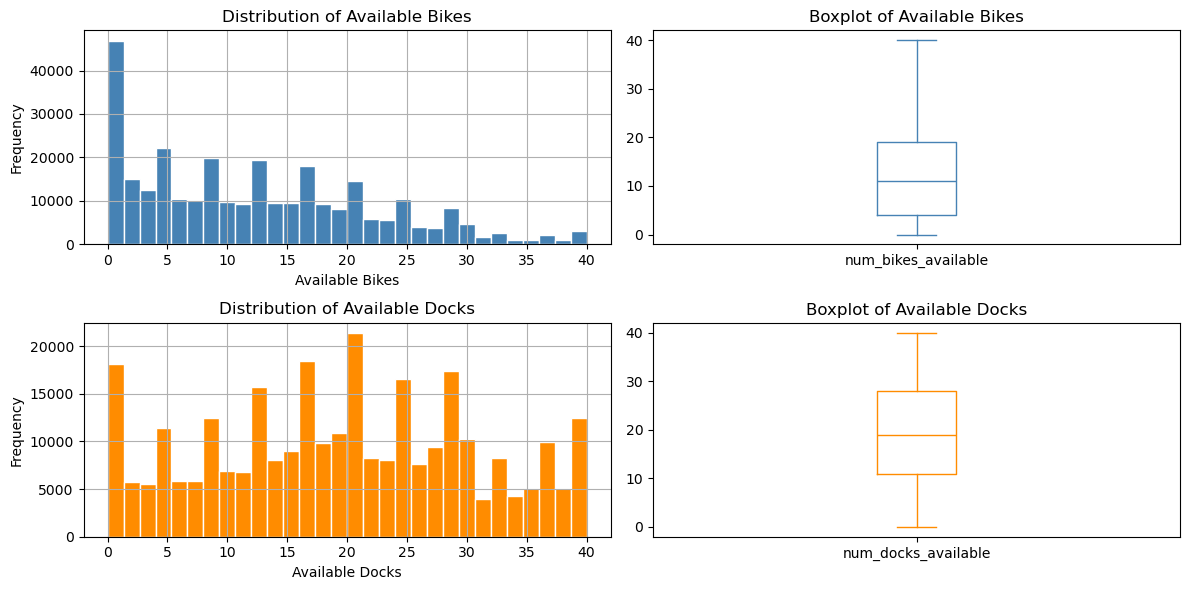

In [7]:
# Target variables
targets = ['num_bikes_available', 'num_docks_available']

print("Target Variables Summary:")

for col in targets:
    print(f"\n🔹 {col}")
    print(df[col].describe())

# Visualization
plt.figure(figsize=(12, 6))

# --- num_bikes_available ---
plt.subplot(2, 2, 1)
df['num_bikes_available'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Available Bikes')
plt.xlabel('Available Bikes')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
df['num_bikes_available'].plot(kind='box', color='steelblue')
plt.title('Boxplot of Available Bikes')

# --- num_docks_available ---
plt.subplot(2, 2, 3)
df['num_docks_available'].hist(bins=30, color='darkorange', edgecolor='white')
plt.title('Distribution of Available Docks')
plt.xlabel('Available Docks')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
df['num_docks_available'].plot(kind='box', color='darkorange')
plt.title('Boxplot of Available Docks')

plt.tight_layout()
plt.show()

Removed 36 constant columns:
['is_installed', 'is_renting', 'is_returning', 'stno', 'year', 'month', 'max_air_temp_quality_indicator', 'min_air_temp_quality_indicator', 'air_temp_std_quality_indicator', 'max_grass_temp_quality_indicator', 'min_grass_temp_quality_indicator', 'grass_temp_std_quality_indicator', 'max_soil_temp_5cm_quality_indicator', 'min_soil_temp_5cm_quality_indicator', 'soil_temp_std_5cm_quality_indicator', 'max_soil_temp_10cm_quality_indicator', 'min_soil_temp_10cm_quality_indicator', 'soil_temp_std_10cm_quality_indicator', 'max_soil_temp_20cm_quality_indicator', 'min_soil_temp_20cm_quality_indicator', 'soil_temp_std_20cm_quality_indicator', 'max_earth_temp_30cm_quality_indicator', 'min_earth_temp_30cm_quality_indicator', 'earth_temp_std_30cm_quality_indicator', 'max_earth_temp_50cm_quality_indicator', 'min_earth_temp_50cm_quality_indicator', 'earth_temp_std_50cm_quality_indicator', 'max_earth_temp_100cm_quality_indicator', 'min_earth_temp_100cm_quality_indicator', 'e

,Absolute Correlation
num_docks_available,0.717459
capacity,0.205051
lat,0.137569
lon,0.124585
min_relative_humidity_percent,0.008731
max_relative_humidity_percent,0.008561
relative_humidity_std_deviation,0.004819
hour,0.004754
min_soil_temperature_10cm_celsius,0.004238
max_soil_temperature_10cm_celsius,0.004229



Correlation with num_docks_available


,Absolute Correlation
num_bikes_available,0.717459
capacity,0.458782
station_id,0.366873
lon,0.112173
lat,0.092340
hour,0.017044
max_air_temperature_celsius,0.008805
min_air_temperature_celsius,0.008775
min_soil_temperature_5cm_celsius,0.006025
max_soil_temperature_5cm_celsius,0.006010



Top 10 features for num_bikes_available:
['num_docks_available', 'capacity', 'lat', 'lon', 'min_relative_humidity_percent', 'max_relative_humidity_percent', 'relative_humidity_std_deviation', 'hour', 'min_soil_temperature_10cm_celsius', 'max_soil_temperature_10cm_celsius']

Top 10 features for num_docks_available:
['num_bikes_available', 'capacity', 'station_id', 'lon', 'lat', 'hour', 'max_air_temperature_celsius', 'min_air_temperature_celsius', 'min_soil_temperature_5cm_celsius', 'max_soil_temperature_5cm_celsius']


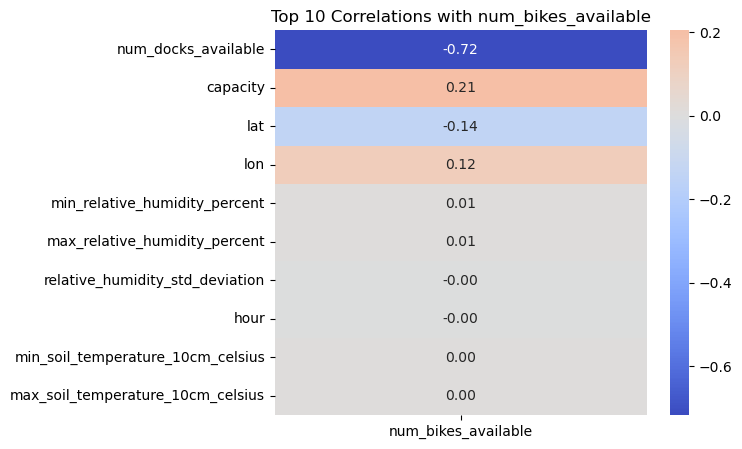

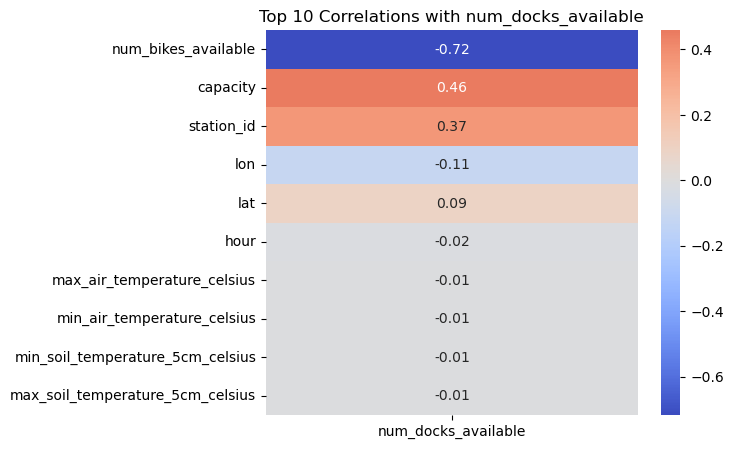

In [8]:
# =========================
# Step 1: Initial feature filtering
# =========================

# 1. Remove constant columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

print(f"Removed {len(constant_cols)} constant columns:")
print(constant_cols)

df_filtered = df.drop(columns=constant_cols).copy()

# 2. Check shape after filtering
print(f"\nRemaining dataset shape: {df_filtered.shape}")

# =========================
# Step 2: Select numeric features
# =========================

numeric_df = df_filtered.select_dtypes(include=['number']).copy()

print(f"Number of numeric columns: {numeric_df.shape[1]}")
print(numeric_df.columns.tolist())

# =========================
# Step 3: Correlation with targets
# =========================

targets = ['num_bikes_available', 'num_docks_available']

for target in targets:
    print(f"\nCorrelation with {target}")

    corr_with_target = numeric_df.corr()[target].drop(target)
    corr_with_target = corr_with_target.abs().sort_values(ascending=False)

    display(corr_with_target.to_frame(name='Absolute Correlation'))

# =========================
# Step 4: Keep top correlated features
# =========================

top_n = 10
top_features_dict = {}

for target in targets:
    corr_with_target = numeric_df.corr()[target].drop(target)
    corr_with_target = corr_with_target.abs().sort_values(ascending=False)

    top_features = corr_with_target.head(top_n).index.tolist()
    top_features_dict[target] = top_features

    print(f"\nTop {top_n} features for {target}:")
    print(top_features)

# =========================
# Step 5: Heatmap for selected features
# =========================

target = 'num_bikes_available'
top_n = 10

corr_with_target = numeric_df.corr()[target].drop(target)
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False).head(top_n)

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_with_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    cbar=True
)

plt.title(f'Top {top_n} Correlations with {target}')
plt.show()

target = 'num_docks_available'
top_n = 10

corr_with_target = numeric_df.corr()[target].drop(target)
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False).head(top_n)

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_with_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    cbar=True
)

plt.title(f'Top {top_n} Correlations with {target}')
plt.show()



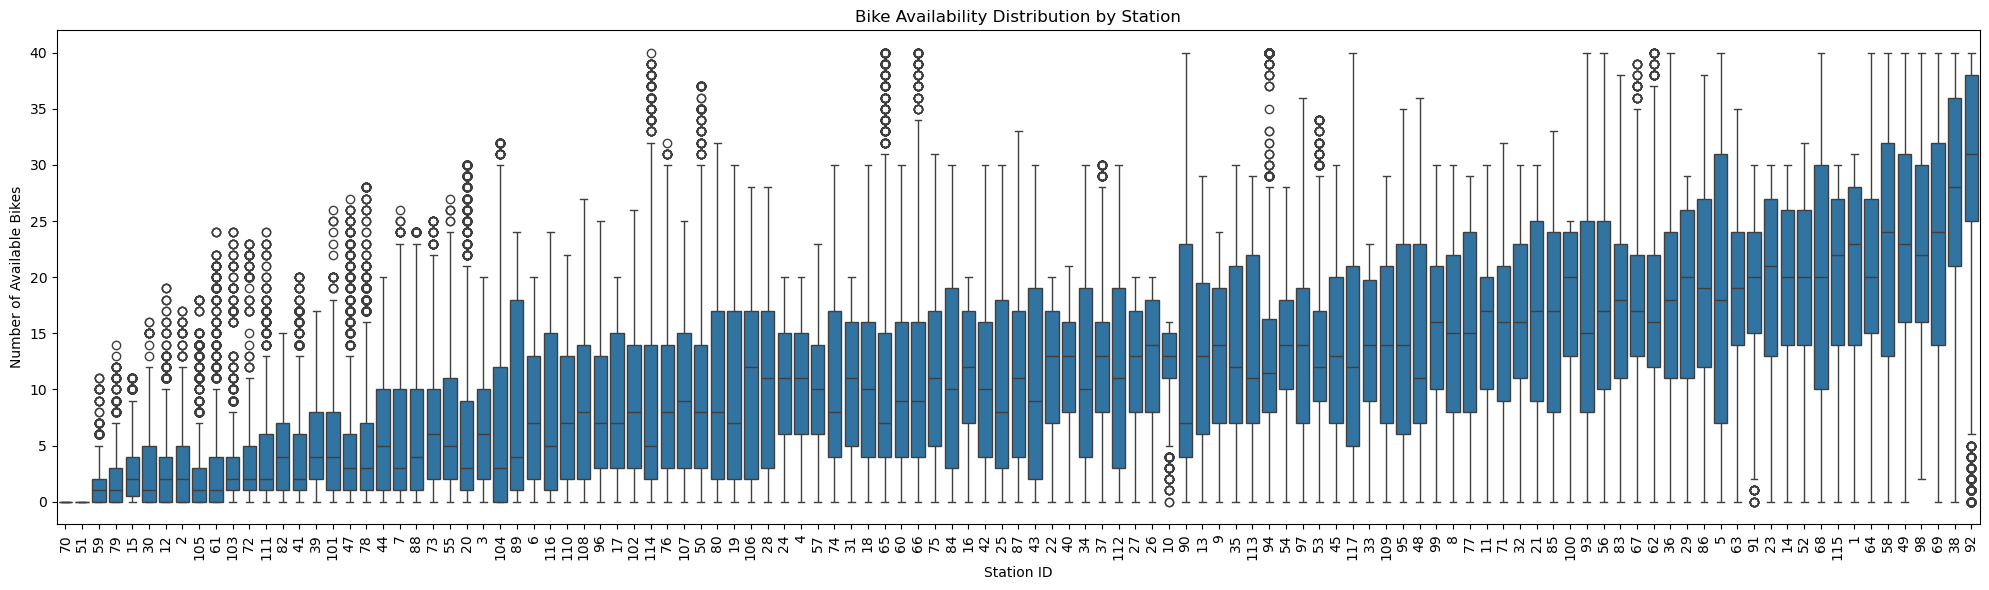

In [9]:
# =========================
# Analyse station_id vs target
# =========================

# Step 1: Calculate average bike availability per station
order = (
    df.groupby('station_id')['num_bikes_available']
      .mean()
      .sort_values()
      .index
)

# Step 2: Plot boxplot
plt.figure(figsize=(20, 6))

sns.boxplot(
    x='station_id',
    y='num_bikes_available',
    data=df,
    order=order
)

# Step 3: Improve readability
plt.xticks(rotation=90)
plt.xlabel('Station ID')
plt.ylabel('Number of Available Bikes')
plt.title('Bike Availability Distribution by Station')

plt.tight_layout()
plt.show()

The boxplot shows clear differences in bike availability across stations.
Each station exhibits its own distribution pattern, indicating that station_id carries important information for prediction.

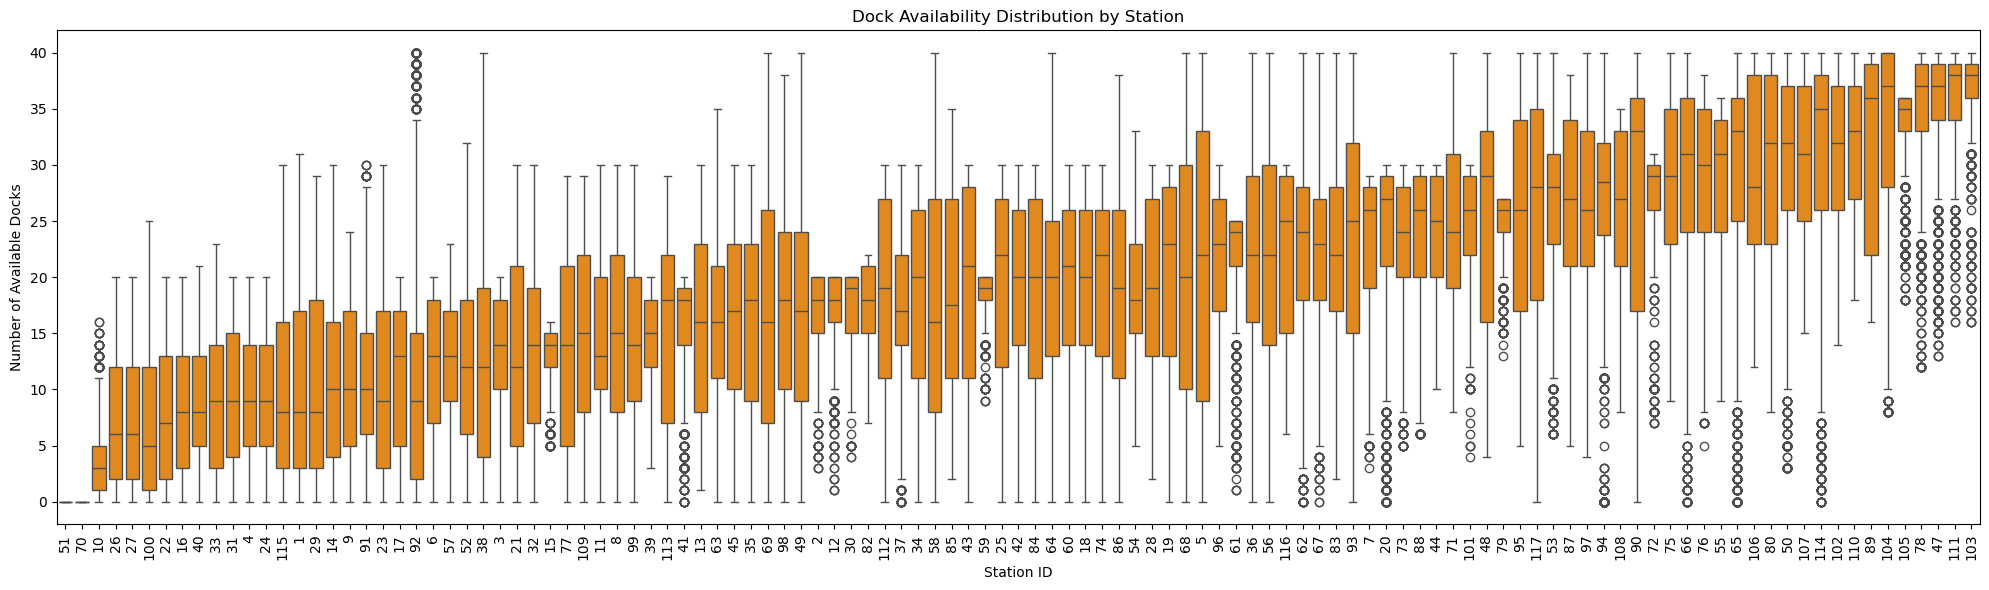

In [10]:
# =========================
# Analyse station_id vs num_docks_available
# =========================

# Step 1: Calculate average dock availability per station
order = (
    df.groupby('station_id')['num_docks_available']
      .mean()
      .sort_values()
      .index
)

# Step 2: Plot boxplot
plt.figure(figsize=(20, 6))

sns.boxplot(
    x='station_id',
    y='num_docks_available',
    data=df,
    order=order,
    color='darkorange'
)

# Step 3: Improve readability
plt.xticks(rotation=90)  
plt.xlabel('Station ID')
plt.ylabel('Number of Available Docks')
plt.title('Dock Availability Distribution by Station')

plt.tight_layout()
plt.show()

The boxplot shows clear differences in docks availability across stations.
Each station exhibits its own distribution pattern, indicating that station_id carries important information for prediction.

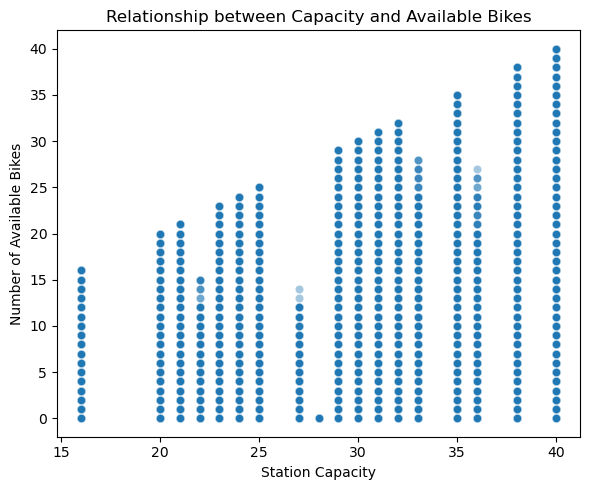

In [11]:
# =========================
# Analyse capacity vs num_bikes_available
# =========================

# Step 1: Plot scatter plot
plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=df,
    x='capacity',
    y='num_bikes_available',
    alpha=0.4 
)

# Step 2: Improve readability
plt.xlabel('Station Capacity')
plt.ylabel('Number of Available Bikes')
plt.title('Relationship between Capacity and Available Bikes')

plt.tight_layout()
plt.show()

Capacity is a fixed attribute of each station and is available at prediction time. Although it is related to bike availability through the station constraint, it does not directly determine the target since the number of available docks is unknown. Therefore, capacity is included as a feature, representing the upper bound of bike availability.

# 4. Feature Engineering

### Feature Engineering: Temporal Features

Although time-related features showed weak linear relationships in the correlation analysis, temporal patterns may still influence bike availability.

To capture this, *day_of_week* was extracted from the timestamp (*last_reported*), *is_weekend* was created to distinguish between weekdays and weekends, and *hour* was encoded using sine and cosine transformations to reflect its cyclical nature.

In [12]:
# =========================
# Feature Engineering: Extract day of week
# =========================

# Step 1: Convert timestamp to datetime
df['last_reported'] = pd.to_datetime(df['last_reported'])

# Step 2: Extract day of week (0 = Monday, 6 = Sunday)
df['day_of_week'] = df['last_reported'].dt.dayofweek

# Step 3: Quick check
print("Sample values:")
print(df['day_of_week'].head())

print("\nUnique values:")
print(sorted(df['day_of_week'].unique()))

Sample values:
0    6
1    6
2    6
3    6
4    6
Name: day_of_week, dtype: int32

Unique values:
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]


In [13]:
# =========================
# Feature Engineering: Weekend indicator
# =========================

# Step: Create weekend flag (1 = weekend, 0 = weekday)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Quick check
print(df[['day_of_week', 'is_weekend']].head())

   day_of_week  is_weekend
0            6           1
1            6           1
2            6           1
3            6           1
4            6           1


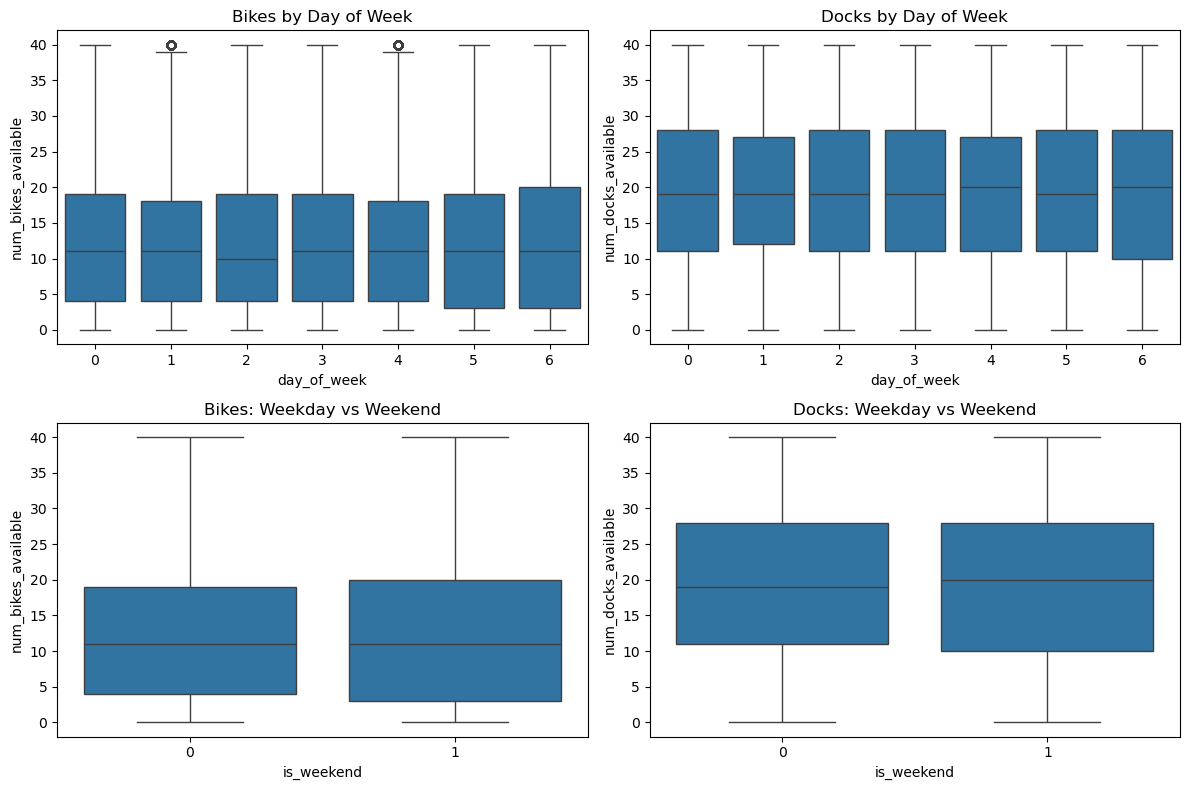

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Day of week - bikes
sns.boxplot(x='day_of_week', y='num_bikes_available', data=df, ax=axes[0,0])
axes[0,0].set_title('Bikes by Day of Week')

# Day of week - docks
sns.boxplot(x='day_of_week', y='num_docks_available', data=df, ax=axes[0,1])
axes[0,1].set_title('Docks by Day of Week')

# Weekend - bikes
sns.boxplot(x='is_weekend', y='num_bikes_available', data=df, ax=axes[1,0])
axes[1,0].set_title('Bikes: Weekday vs Weekend')

# Weekend - docks
sns.boxplot(x='is_weekend', y='num_docks_available', data=df, ax=axes[1,1])
axes[1,1].set_title('Docks: Weekday vs Weekend')

plt.tight_layout()
plt.show()

The distributions are similar across all days and between weekdays and weekends, with no clear differences in bike or dock availability.
Weekly patterns have limited impact, which is consistent with the weak correlations observed earlier.
However, these features may still be useful when combined with other variables, such as station or time of day.

In [15]:
# =========================
# Feature Engineering: Cyclical encoding of hour
# =========================

# Step 1: Create cyclical features
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Step 2: Quick check
print(df[['hour', 'hour_sin', 'hour_cos']].head())

   hour  hour_sin  hour_cos
0     0       0.0       1.0
1     0       0.0       1.0
2     0       0.0       1.0
3     0       0.0       1.0
4     0       0.0       1.0


### Feature Engineering: Weather Features
From the correlation analysis, humidity-related features showed slight relationships with bike availability, while temperature-related features appeared in the correlations with dock availability.

To simplify and stabilise these signals, average temperature and humidity features were created.

In [16]:
# =========================
# Feature Engineering: Average weather features
# =========================

# Average air temperature
df['avg_air_temperature'] = (
    df['min_air_temperature_celsius'] +
    df['max_air_temperature_celsius']
) / 2

# Average relative humidity
df['avg_relative_humidity'] = (
    df['min_relative_humidity_percent'] +
    df['max_relative_humidity_percent']
) / 2

# Quick check
print(df[['avg_air_temperature', 'avg_relative_humidity']].head())

   avg_air_temperature  avg_relative_humidity
0               13.955                  83.75
1               13.955                  83.75
2               13.955                  83.75
3               13.955                  83.75
4               13.955                  83.75


### Feature Engineering: Station Mean

As *station_id* cannot be directly used in linear models, *station_mean* was created to capture station-specific patterns numerically.

In [17]:
# Linear models cannot directly use station_id as it is a categorical variable.
# Therefore, station_mean is created to capture station-specific patterns in a numerical form.

# Split
X = df.drop(columns=['num_bikes_available', 'num_docks_available'])
y = df[['num_bikes_available', 'num_docks_available']]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Build train_df
train_df = X_train.copy()
train_df['num_bikes_available'] = y_train['num_bikes_available']

# Compute station mean
station_mean = train_df.groupby('station_id')['num_bikes_available'].mean()

# Map to train & test
X_train['station_mean'] = X_train['station_id'].map(station_mean)
X_test['station_mean'] = X_test['station_id'].map(station_mean)

# Handle unseen stations
global_mean = y_train['num_bikes_available'].mean()
X_test['station_mean'] = X_test['station_mean'].fillna(global_mean)


In [18]:
X_train.head(5)

,last_reported,station_id,is_installed,is_renting,is_returning,name,address,lat,lon,capacity,...,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation,day_of_week,is_weekend,hour_sin,hour_cos,avg_air_temperature,avg_relative_humidity,station_mean
30937,2024-12-04 01:20:00,4,True,True,True,GREEK STREET,Greek Street,53.346874,-6.272976,20,...,1017.93,0,0.064,2,0,0.258819,0.965926,7.0880,96.750,10.619830
15591,2024-12-02 13:50:00,112,True,True,True,NORTH CIRCULAR ROAD (O'CONNELL'S),North Circular Road (O'Connell's),53.357840,-6.251557,30,...,1014.15,0,0.034,0,0,-0.258819,-0.965926,6.0360,68.655,12.274127
256558,2024-12-27 09:40:00,95,True,True,True,ROYAL HOSPITAL,Royal Hospital,53.343900,-6.297060,40,...,1026.23,0,0.006,4,0,0.707107,-0.707107,7.6475,95.050,14.551775
191800,2024-12-20 09:10:00,8,True,True,True,CUSTOM HOUSE QUAY,Custom House Quay,53.347885,-6.248048,30,...,1007.18,0,0.072,4,0,0.707107,-0.707107,7.3740,89.150,15.011375
11333,2024-12-02 05:30:00,75,True,True,True,JAMES STREET,James Street,53.343456,-6.287409,40,...,1007.44,0,0.054,0,0,0.965926,0.258819,6.2740,85.550,11.259620


# 5. Feature Pairing

### Bike Availability by Day of Week Across Top Stations

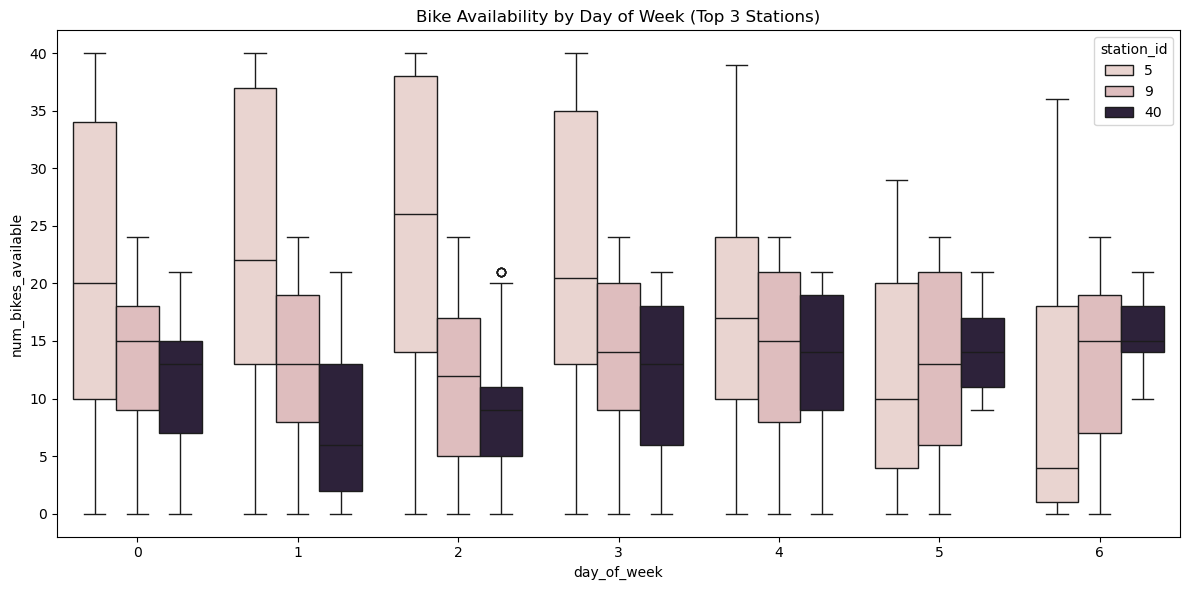

In [19]:
stations = df['station_id'].value_counts().head(3).index
df_sub = df[df['station_id'].isin(stations)].copy()

if str(df_sub['station_id'].dtype) == 'category':
    df_sub['station_id'] = df_sub['station_id'].cat.remove_unused_categories()

plt.figure(figsize=(12,6))

sns.boxplot(
    x='day_of_week',
    y='num_bikes_available',
    hue='station_id',
    data=df_sub,
    order=[0, 1, 2, 3, 4, 5, 6]
)

plt.title('Bike Availability by Day of Week (Top 3 Stations)')
plt.tight_layout()
plt.show()

Bike availability varies significantly across stations, with station 5 showing higher availability and greater variability compared to others. The effect of day_of_week is relatively weak, although some stations exhibit slightly lower availability during weekends.

### Hourly Bike Availability Across Top Stations

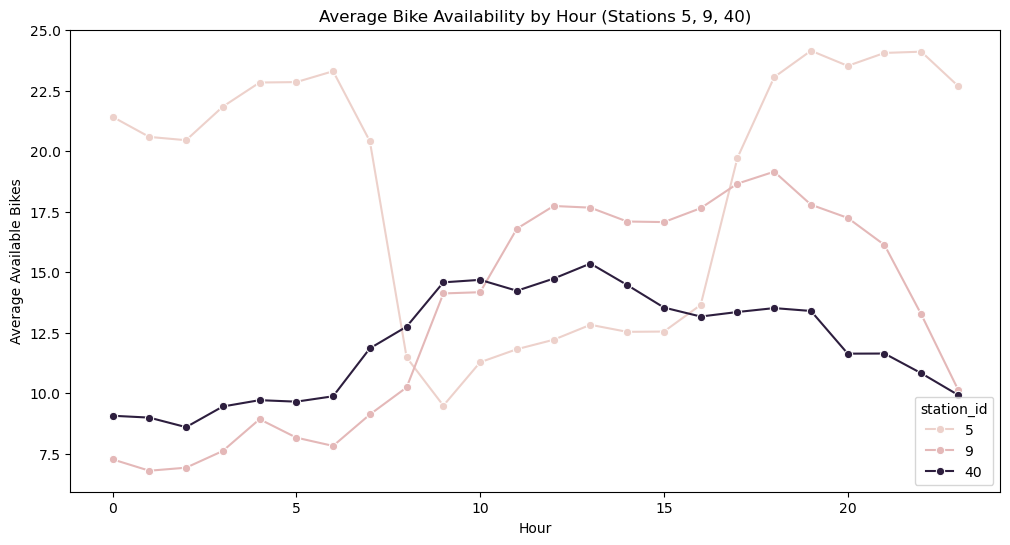

In [20]:
stations = [5, 9, 40]

df_sub = df[df['station_id'].isin(stations)].copy()


if str(df_sub['station_id'].dtype) == 'category':
    df_sub['station_id'] = df_sub['station_id'].cat.remove_unused_categories()

df_grouped = (
    df_sub.groupby(['hour', 'station_id'])['num_bikes_available']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_grouped,
    x='hour',
    y='num_bikes_available',
    hue='station_id',
    hue_order=stations, 
    marker='o'
)

plt.title('Average Bike Availability by Hour (Stations 5, 9, 40)')
plt.xlabel('Hour')
plt.ylabel('Average Available Bikes')
plt.show()

The plot reveals strong hourly patterns in bike availability, with significant differences across stations. The relationship between hour and bike availability is clearly non-linear, as availability fluctuates throughout the day rather than following a monotonic trend. Furthermore, the shape of this relationship varies across stations, indicating a strong interaction effect between station location and hourly demand.

# 6. Feature Selection

### Feature Selection for Linear Models

For linear models, features were selected based on their numerical meaning and linear interpretability.

Station information was represented using *station_mean*, as *station_id* cannot be directly used in linear models.  
Cyclical encoding (*hour_sin*, *hour_cos*) was applied to capture daily patterns.  

Weather variables were simplified using average values to reduce noise.  

The feature *day_of_week* was excluded due to its lack of meaningful numerical ordering.  
Instead, *is_weekend* was retained as a simpler and more interpretable representation.

In [21]:
# =========================
# Features for Linear Model
# =========================

linear_features = [
    'station_mean',              # encode station effect
    'capacity',                 # station size
    'hour_sin', 'hour_cos',     # cyclical time
    'avg_air_temperature',      # simplified weather
    'avg_relative_humidity',    # simplified weather
    'is_weekend'
]

X_train_linear = X_train[linear_features]
X_test_linear = X_test[linear_features]

print("📊 Linear Model Dataset Info:")
print(f"Train size: {X_train_linear.shape[0]:,} rows")
print(f"Test size: {X_test_linear.shape[0]:,} rows")
print(f"Number of features: {len(linear_features)}")
print(f"Feature list: {linear_features}")

📊 Linear Model Dataset Info:
Train size: 209,262 rows
Test size: 89,684 rows
Number of features: 7
Feature list: ['station_mean', 'capacity', 'hour_sin', 'hour_cos', 'avg_air_temperature', 'avg_relative_humidity', 'is_weekend']


### Feature Selection for Non-linear Models

For tree-based models, a broader set of features was used.

Unlike linear models, tree-based models can handle categorical and non-linear relationships. Therefore, *station_id* was used directly, along with temporal features such as *hour*, *day_of_week*. The feature *is_weekend* was not included, as its information is already captured by *day_of_week*.

Spatial features (*lat*, *lon*) and weather variables were also included, as tree models can capture complex interactions between variables.

In [22]:
# =========================
# Features for Tree-based Models
# =========================

tree_features = [
    'station_id',               # categorical feature
    'capacity',
    'day',
    'hour',                     # raw hour is OK
    'day_of_week',              
    'lat', 'lon',               # spatial info
    'avg_air_temperature',
    'avg_relative_humidity'
]

X_train_tree = X_train[tree_features]
X_test_tree = X_test[tree_features]

print("\nTree-based Model Dataset Info:")
print(f"Train size: {X_train_tree.shape[0]:,} rows")
print(f"Test size: {X_test_tree.shape[0]:,} rows")
print(f"Number of features: {len(tree_features)}")
print(f"Feature list: {tree_features}")


Tree-based Model Dataset Info:
Train size: 209,262 rows
Test size: 89,684 rows
Number of features: 9
Feature list: ['station_id', 'capacity', 'day', 'hour', 'day_of_week', 'lat', 'lon', 'avg_air_temperature', 'avg_relative_humidity']


# 7. Model Training & Comparison

### Models Overview

We trained and compared five regression models:

| Model                | Description |
|---------------------|------------|
| Linear Regression   | A baseline linear model that assumes a linear relationship between features and target variables |
| Lasso Regression    | A linear model with L1 regularisation, which can perform feature selection by shrinking some coefficients to zero |
| Ridge Regression    | A linear model with L2 regularisation, which helps reduce overfitting by penalising large coefficients |
| Random Forest       | An ensemble tree-based model that captures non-linear relationships and interactions between features |
| Gradient Boosting   | A boosting-based model that builds trees sequentially to improve performance and reduce errors |

In [23]:
# =========================
# 1. Define targets
# =========================
target_cols = ['num_bikes_available', 'num_docks_available']

# =========================
# 2. Build model inputs
# =========================
X_train_linear = X_train[linear_features].copy()
X_test_linear = X_test[linear_features].copy()

X_train_tree = X_train[tree_features].copy()
X_test_tree = X_test[tree_features].copy()

# Scale linear features for regularised models
scaler = StandardScaler()
X_train_linear_scaled = scaler.fit_transform(X_train_linear)
X_test_linear_scaled = scaler.transform(X_test_linear)

# =========================
# 3. Define models
# =========================
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'feature_type': 'linear_raw'
    },
    'Lasso': {
        'model': MultiOutputRegressor(
            Lasso(alpha=0.01, max_iter=10000, random_state=42)
        ),
        'feature_type': 'linear_scaled'
    },
    'Ridge Regression': {
        'model': Ridge(alpha=10.0, random_state=42),
        'feature_type': 'linear_scaled'
    },
    'Random Forest': {
        'model': RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ),
        'feature_type': 'tree'
    },
    'Gradient Boosting': {
        'model': MultiOutputRegressor(
            GradientBoostingRegressor(
                n_estimators=100,
                random_state=42
            )
        ),
        'feature_type': 'tree'
    }
}

# =========================
# 4. Train and evaluate
# =========================
results = []

for model_name, config in models.items():
    print(f"Training {model_name}...")

    model = config['model']
    feature_type = config['feature_type']

    # Select feature set based on model type
    if feature_type == 'linear_raw':
        X_train_model = X_train_linear
        X_test_model = X_test_linear
        feature_set_name = 'linear'
    elif feature_type == 'linear_scaled':
        X_train_model = X_train_linear_scaled
        X_test_model = X_test_linear_scaled
        feature_set_name = 'linear_scaled'
    else:
        X_train_model = X_train_tree
        X_test_model = X_test_tree
        feature_set_name = 'tree'

    # Fit model
    model.fit(X_train_model, y_train)

    # Predict on train and test
    y_train_pred = model.predict(X_train_model)
    y_test_pred = model.predict(X_test_model)

    # Evaluate each target separately
    for i, target in enumerate(target_cols):
        train_mae = mean_absolute_error(y_train[target], y_train_pred[:, i])
        train_rmse = np.sqrt(mean_squared_error(y_train[target], y_train_pred[:, i]))
        train_r2 = r2_score(y_train[target], y_train_pred[:, i])

        test_mae = mean_absolute_error(y_test[target], y_test_pred[:, i])
        test_rmse = np.sqrt(mean_squared_error(y_test[target], y_test_pred[:, i]))
        test_r2 = r2_score(y_test[target], y_test_pred[:, i])

        results.append({
            'Model': model_name,
            'Feature Set': feature_set_name,
            'Target': target,
            'Train MAE': round(train_mae, 4),
            'Train RMSE': round(train_rmse, 4),
            'Train R2': round(train_r2, 4),
            'Test MAE': round(test_mae, 4),
            'Test RMSE': round(test_rmse, 4),
            'Test R2': round(test_r2, 4)
        })

# =========================
# 5. Results table
# =========================
results_df = pd.DataFrame(results)

print("\nModel comparison completed.")
display(results_df)

Training Linear Regression...
Training Lasso...
Training Ridge Regression...
Training Random Forest...
Training Gradient Boosting...

Model comparison completed.


,Model,Feature Set,Target,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Linear Regression,linear,num_bikes_available,6.2865,7.8940,0.3475,6.2565,7.8643,0.3476
1,Linear Regression,linear,num_docks_available,6.7550,8.6079,0.3883,6.7542,8.6341,0.3830
2,Lasso,linear_scaled,num_bikes_available,6.2874,7.8940,0.3475,6.2573,7.8643,0.3476
3,Lasso,linear_scaled,num_docks_available,6.7577,8.6080,0.3882,6.7568,8.6340,0.3830
4,Ridge Regression,linear_scaled,num_bikes_available,6.2865,7.8940,0.3475,6.2565,7.8643,0.3476
5,Ridge Regression,linear_scaled,num_docks_available,6.7551,8.6079,0.3883,6.7543,8.6341,0.3830
6,Random Forest,tree,num_bikes_available,2.4566,3.5970,0.8645,2.5858,3.7534,0.8514
7,Random Forest,tree,num_docks_available,2.4593,3.5990,0.8931,2.5912,3.7588,0.8831
8,Gradient Boosting,tree,num_bikes_available,6.1404,7.5707,0.3999,6.1182,7.5501,0.3986
9,Gradient Boosting,tree,num_docks_available,6.1747,7.6071,0.5222,6.1517,7.5862,0.5237


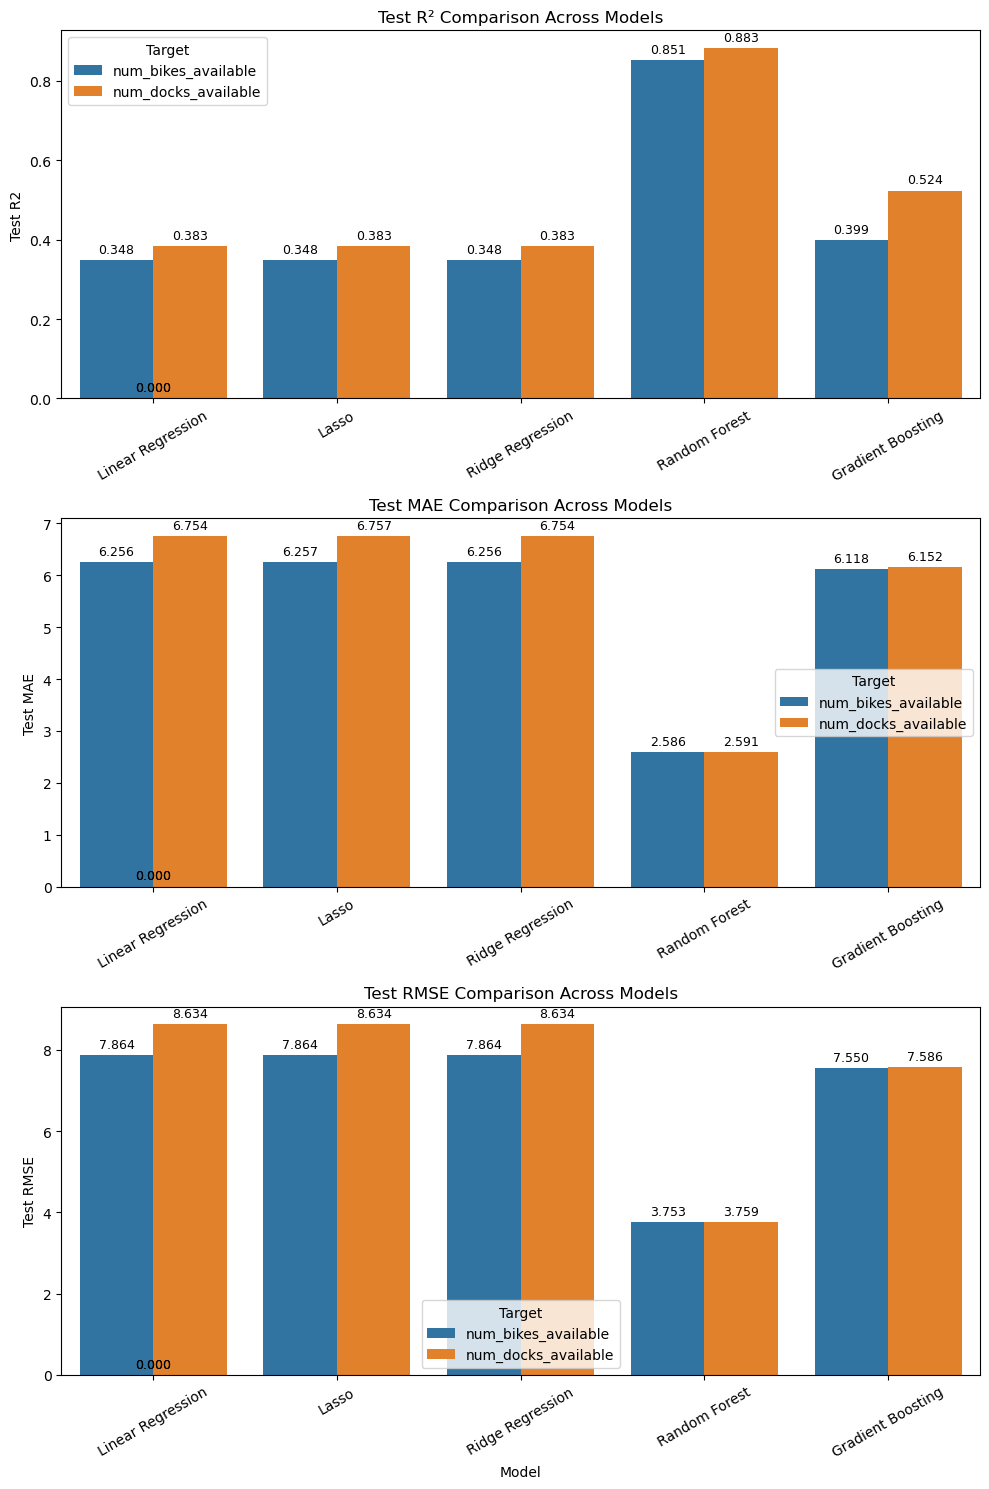

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# ===== Function to add labels =====
def add_labels(ax):
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height):
            ax.annotate(f'{height:.3f}',
                        (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom',
                        fontsize=9,
                        xytext=(0, 3),
                        textcoords='offset points')

# =========================
# Test R²
# =========================
sns.barplot(
    data=results_df,
    x='Model',
    y='Test R2',
    hue='Target',
    ax=axes[0]
)
axes[0].set_title('Test R² Comparison Across Models')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

add_labels(axes[0])

# =========================
# Test MAE
# =========================
sns.barplot(
    data=results_df,
    x='Model',
    y='Test MAE',
    hue='Target',
    ax=axes[1]
)
axes[1].set_title('Test MAE Comparison Across Models')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

add_labels(axes[1])

# =========================
# Test RMSE
# =========================
sns.barplot(
    data=results_df,
    x='Model',
    y='Test RMSE',
    hue='Target',
    ax=axes[2]
)
axes[2].set_title('Test RMSE Comparison Across Models')
axes[2].tick_params(axis='x', rotation=30)

add_labels(axes[2])

plt.tight_layout()
plt.show()

### Model Comparison

Random Forest performed best across both targets, with lower errors and higher R² scores on the test set. This suggests it captures the data patterns more effectively.

The linear models (Linear Regression, Lasso, and Ridge) showed very similar results, but their overall performance was much weaker. A simple linear relationship is not sufficient to describe the data.

Gradient Boosting improved on the linear models, particularly for dock availability, but still fell short of Random Forest.

# 8. Model Selection & Interpretation 

Based on the comparison above, Random Forest was selected as the final model.

Feature importance ranking:
lat                      0.232517
capacity                 0.177338
day                      0.152854
lon                      0.131618
hour                     0.096811
day_of_week              0.073582
station_id               0.067794
avg_air_temperature      0.036556
avg_relative_humidity    0.030929
dtype: float64


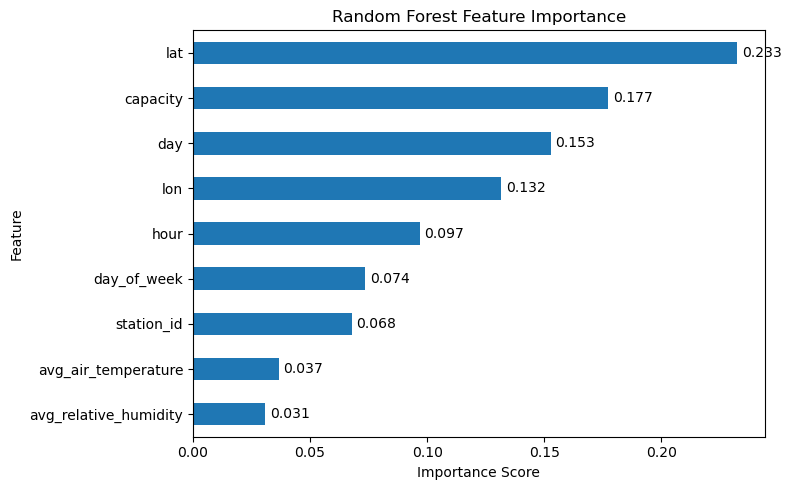

In [25]:
# =========================
# Feature Importance: Random Forest
# =========================

rf_model = models['Random Forest']['model']

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=tree_features
).sort_values(ascending=False)

print("Feature importance ranking:")
print(feature_importance)

# Plot
plt.figure(figsize=(8, 5))
ax = feature_importance.sort_values().plot(kind='barh')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# Add labels to bars
for i, v in enumerate(feature_importance.sort_values()):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()

# 9. Model Saving

In [26]:
# Save best model (Random Forest)
best_model = models['Random Forest']['model']
joblib.dump(best_model, "bike_model.joblib")

# Save feature order
joblib.dump(tree_features, "model_features.joblib")

print("Model saved: bike_model.joblib")
print("Feature order saved: model_features.joblib")

Model saved: bike_model.joblib
Feature order saved: model_features.joblib


# 10. Model Prediction Example

In [27]:
# Load model and feature order
model = joblib.load("bike_model.joblib")
features = joblib.load("model_features.joblib")

print("Model features:")
print(features)

# ---- Simulated input (test data) ----
sample_input = X_test[features].sample(1, random_state=42)

print("\nSample input:")
display(sample_input)

# Predict
prediction = model.predict(sample_input)

# Output results
print("Prediction:", prediction)
print("Predicted bikes:", round(prediction[0][0], 2))
print("Predicted docks:", round(prediction[0][1], 2))


# Compare with real data
actual = y_test.loc[sample_input.index[0]]

print("\nActual values:")
print("Actual bikes:", actual['num_bikes_available'])
print("Actual docks:", actual['num_docks_available'])

# Calculate error
error_bikes = abs(prediction[0][0] - actual['num_bikes_available'])
error_docks = abs(prediction[0][1] - actual['num_docks_available'])

print("\nPrediction Error:")
print("Bike error:", round(error_bikes, 2))
print("Dock error:", round(error_docks, 2))

Model features:
['station_id', 'capacity', 'day', 'hour', 'day_of_week', 'lat', 'lon', 'avg_air_temperature', 'avg_relative_humidity']

Sample input:


,station_id,capacity,day,hour,day_of_week,lat,lon,avg_air_temperature,avg_relative_humidity
271989,39,20,29,0,6,53.332382,-6.252717,7.6925,91.9


Prediction: [[ 3.8436447  16.13940583]]
Predicted bikes: 3.84
Predicted docks: 16.14

Actual values:
Actual bikes: 4
Actual docks: 16

Prediction Error:
Bike error: 0.16
Dock error: 0.14


## Final Model Summary

| Item | Description |
|------|-------------|
| Model | Random Forest |
| Model Files | bike_model.joblib (trained model), model_features.joblib (feature order) |
| Target Variables | num_bikes_available, num_docks_available |
| Input Features | station_id, capacity, day, hour, day_of_week, lat, lon, avg_air_temperature, avg_relative_humidity |

## Input Feature Description

| Feature | Description |
|--------|------------|
| station_id | Station identifier |
| capacity | Station capacity |
| day | Day of month |
| hour | Hour of day |
| day_of_week | Day of week (0–6) |
| lat, lon | Station location |
| avg_air_temperature | Average temperature |
| avg_relative_humidity | Average humidity |